# Phase 2 - Part A: Clustering

**Course:** SWE485 (Selected Topics in Software Engineering)
**Phase:** 2 (Unsupervised Learning)

## 1. Data Preparation 

### 1.1 Feature Scaling
Feature scaling is important in clustering because most clustering algorithms rely on distance calculations to measure similarity between data points. When variables are measured on different scales, features with larger numerical ranges can dominate the distance computation, leading to biased clustering results. For example, a variable such as RestingBP may have larger values compared to Oldpeak, causing it to have a disproportionate influence on cluster formation if not scaled.

Applying feature scaling ensures that all numerical variables contribute equally to the clustering process, allowing clusters to reflect meaningful patterns in the data rather than differences in measurement scale.
In this study, feature scaling was applied during preprocessing done in the EDA phase to continuous variables, including Age, MaxHR, Oldpeak, and RestingBP.

### 1.2 Target Removal

Target removal is necessary in clustering because it is an unsupervised learning task. This means the model should discover patterns and group similar data points without using any predefined labels.
Including the target variable may introduce bias into the clustering results, as it would indirectly guide the model toward known outcomes instead of uncovering natural structures in the data.

### Import Libraries

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from IPython.display import display
from sklearn.cluster import KMeans
import holoviews as hv
from holoviews import opts
from sklearn.manifold import TSNE
import matplotlib.patches as mpatches
import seaborn as sns 
import numpy as np
import warnings
from sklearn.metrics import classification_report

### Load Preprocessed Dataset & Remove Target

In [38]:
# Load dataset including target from supervised lerning phase
DATA_PATH = "Dataset/preprocessed_heart_data.csv"
original_data = pd.read_csv(DATA_PATH)

print(f"Dataset (with target): {original_data.shape}")

# Remove target column for clustering (unsupervised learning)
clustering_data = original_data.drop(columns=["HeartDisease"])

print(f"Clustering data shape: {clustering_data.shape}")
clustering_data.head()

Dataset (with target): (917, 21)
Clustering data shape: (917, 20)


,Age,Sex,RestingBP,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,Chol_category_Desirable,Chol_category_Borderline High,Chol_category_High
0,-1.432206,1,0.5,0,1.383339,0,-0.400000,0,1,0,0,0,1,0,0,0,1,0,0,1
1,-0.478057,0,1.5,0,0.754736,0,0.266667,0,0,1,0,0,1,0,0,1,0,1,0,0
2,-1.750256,1,0.0,0,-1.523953,0,-0.400000,0,1,0,0,0,0,1,0,0,1,0,0,1
3,-0.584074,0,0.4,0,-1.131075,1,0.600000,1,0,0,0,0,1,0,0,1,0,0,1,0
4,0.052026,1,1.0,0,-0.581047,0,-0.400000,0,0,1,0,0,1,0,0,0,1,1,0,0


### 1.3 Distribution of Categorical Features after Target Removal
### PUT IN EDA PHASE  ###

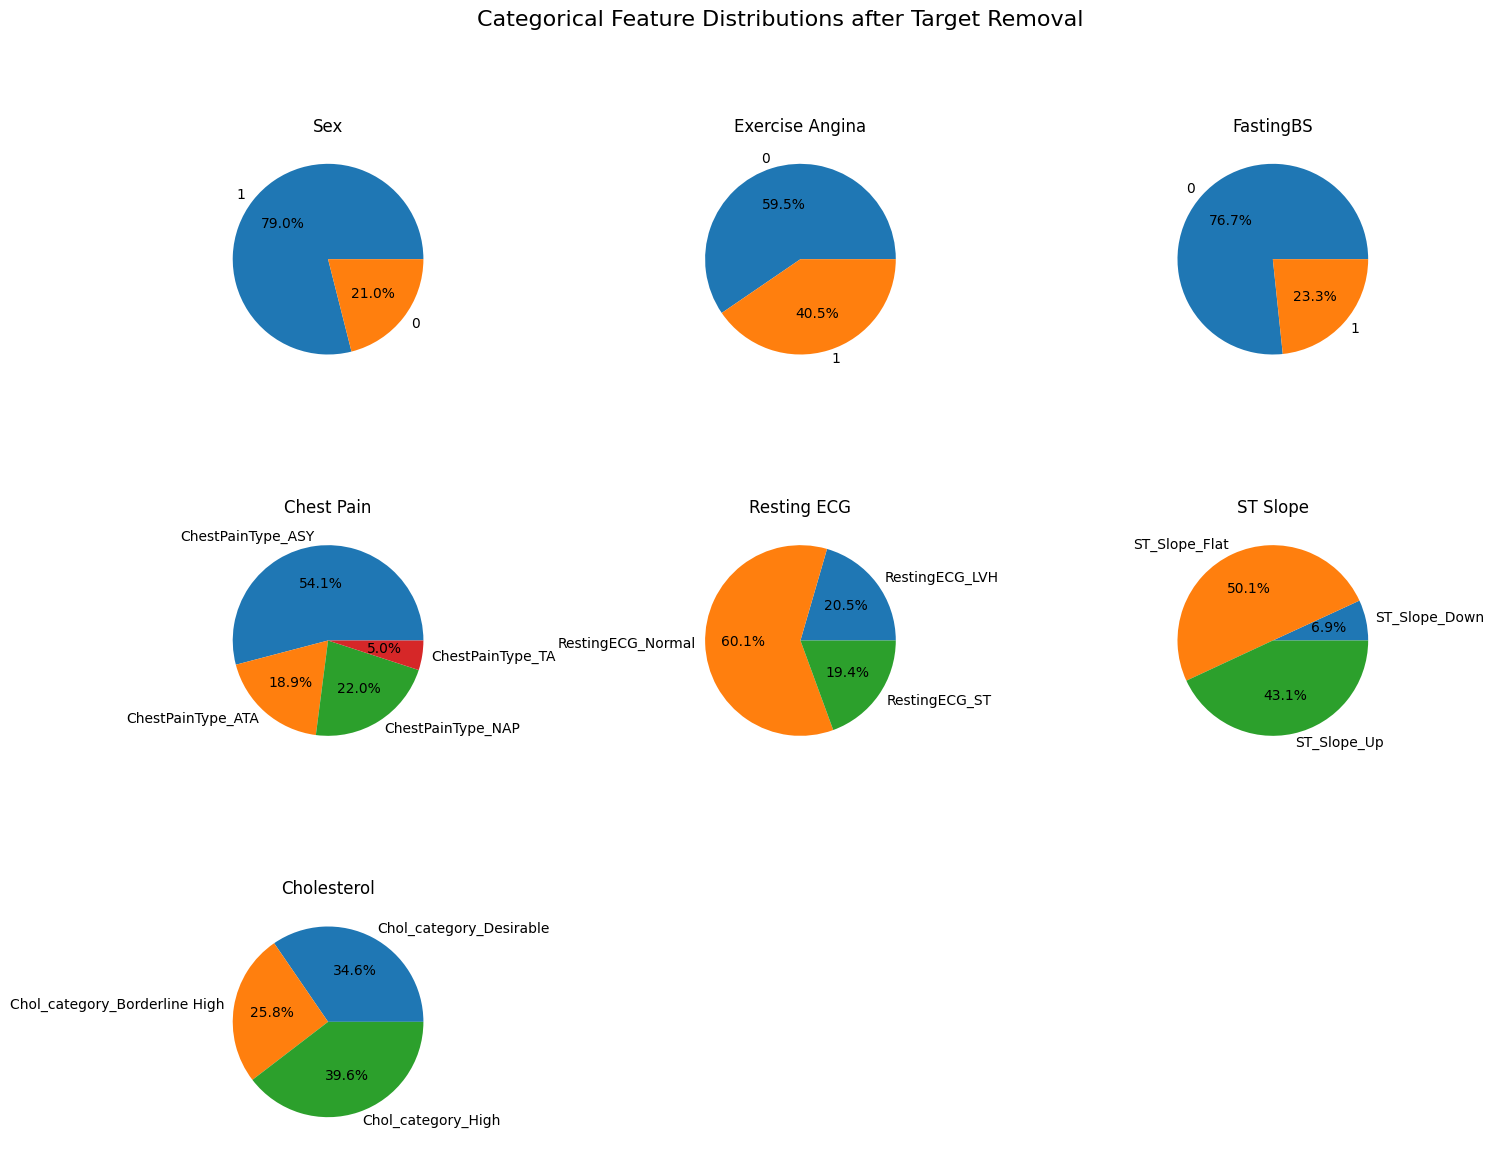

In [40]:
def plot_pie(ax, data, title):
    percentages = data.value_counts(normalize=True) * 100
    ax.pie(percentages, labels=percentages.index, autopct='%1.1f%%')
    ax.set_title(title)

def plot_onehot(ax, df, cols, title):
    counts = df[cols].sum()
    percentages = (counts / counts.sum()) * 100
    ax.pie(percentages, labels=cols, autopct='%1.1f%%')
    ax.set_title(title)

fig, axes = plt.subplots(3, 3, figsize=(16, 13))

# Sex
plot_pie(axes[0,0], clustering_data['Sex'], 'Sex')

# Exercise Angina
plot_pie(axes[0,1], clustering_data['ExerciseAngina'], 'Exercise Angina')

# Fasting Blood Sugar
plot_pie(axes[0,2], clustering_data['FastingBS'], 'FastingBS')

# Chest Pain
plot_onehot(axes[1,0], clustering_data, [
    'ChestPainType_ASY','ChestPainType_ATA','ChestPainType_NAP','ChestPainType_TA'
], 'Chest Pain')

# Resting ECG
plot_onehot(axes[1,1], clustering_data, [
    'RestingECG_LVH','RestingECG_Normal','RestingECG_ST'
], 'Resting ECG')

# ST Slope
plot_onehot(axes[1,2], clustering_data, [
    'ST_Slope_Down','ST_Slope_Flat','ST_Slope_Up'
], 'ST Slope')

# Cholesterol Category
plot_onehot(axes[2,0], clustering_data, [
    'Chol_category_Desirable','Chol_category_Borderline High','Chol_category_High'
], 'Cholesterol')

axes[2,1].axis('off')
axes[2,2].axis('off')

plt.subplots_adjust(wspace=0.6, hspace=0.6)

fig.suptitle('Categorical Feature Distributions after Target Removal', fontsize=16)

plt.show()

## 2. Ability of Data to be Clustered

PUT HERE WHAT U SAID ABOUT HOW WE DO INVESTION BC OF LOW QUALITY (LANA)

To investigate this, two complementary approaches were used: the Hopkins statistic and the Visual Assessment of Tendency (VAT).

The Hopkins statistic is a numerical measure used to quantify the clustering tendency of a dataset. Values close to 0.5 indicate randomness (i.e., no meaningful clusters), while values closer to 1 suggest a strong clustering structure. In this study, the Hopkins value indicated that the dataset has low clusterability, suggesting that the data points are not naturally grouped.

In addition to the numerical measure, the VAT method was applied to visually assess the presence of clusters. VAT produces a reordered dissimilarity matrix, where clear block patterns along the diagonal indicate potential clusters. However, the VAT visualization did not show well-defined block structures, further confirming the weak clustering tendency.

# The Clustering Model Templates Overview




## Section 1. Clustering Rationale & Algorithm Selection
In this section, we justify the selection of each clustering algorithm by considering several key factors, including the size of the dataset and the types of features involved, the expected shapes and structures of the clusters, as well as the scalability of the algorithm and the interpretability of its results.



## Section 2. Cluster Determination & Implementation
In this section, we apply two clustering algorithms. For each algorithm, we first determine the optimal number of clusters, and then perform clustering to assign cluster labels accordingly.

## Section 3. Evaluation Metrics & Visualizations

In this section, we evaluate the clustering results using suitable metrics, each providing a different perspective on cluster quality. 
- ADD METRICS AND THEIR USAGE (LANA)

These evaluation measures help assess how well the clusters are separated, how compact they are, and how meaningful the overall structure is. In addition, we provide visual interpretations of the clusters by projecting them into lower-dimensional space using PCA or t-SNE for better understanding. We also examine feature importance within each cluster to identify the characteristics that distinguish them, along with analyzing the distribution of cluster sizes to gain insight into the balance and representativeness of the formed groups.

## Section 4. Cluster Interpretation & Profiles

In this section, we further interpret the clustering results by profiling each cluster to identify the key characteristics that define each group. This involves examining the dominant features and patterns within each cluster to understand what distinguishes one group from another. Additionally, we relate these clusters to the medical domain, explaining what each group represents in terms of patient profiles or health conditions.

## Section 5. Integration Feasibility and Justification

In this section, we discuss the feasibility of integrating clustering results into the system to enhance personalized, data-driven medical recommendations based on patient groupings. If integration is not feasible, a clear justification is provided, such as weak clustering performance or lack of meaningful clinical interpretation.

## Section 6. Challenges & Limitations

In this section, we discuss the main challenges and limitations encountered during the clustering process, including issues related to data quality, feature representation, and algorithm performance. We also highlight constraints such as weak cluster separation, sensitivity to parameter selection, and potential difficulties in interpreting clusters within the medical context.

---

## **Cluatering Model 1: K-means**

## Section 1. Clustering Rationale & Algorithm Selection

### **What is K-means Algorithm?**
K-Means is a centroid-based clustering algorithm that partitions a dataset into *K* distinct clusters by minimizing the Within-Cluster Sum of Squares (WCSS). It is designed for numerical data, where similarity between data points is measured using a distance mesuare typically Euclidean distance. The algorithm aims to group similar observations together while keeping clusters as compact as possible.

### **Distance Metric**

K-Means uses Euclidean distance to measure similarity:

$$
d(x, \mu) = \sqrt{\sum_{j=1}^{n} (x_j - \mu_j)^2}
$$

- $n$ represents the total number of features.
- $x_j$ is the value of a specific feature.
- $\mu_j$ is the value of the cluster's average for that same feature.

### **How K-Means Works ?**

K-Means follows an iterative optimization process:

1. Initialize *K* cluster centroids randomly  
2. Assign each data point to the nearest centroid  
3. Update each centroid as the mean of its assigned points  
4. Repeat until convergence where cluster assignments stabilize


The algorithm minimizes the Within-Cluster Sum of Squares (WCSS):

$$
\sum_{i=1}^{k} \sum_{x \in C_i} \|x - \mu_i\|^2
$$

- \($C_i$) is cluster \(i\)  
- \($x$) is a data point  
- \($\mu_j$) is the centroid of cluster \(i\)

This objective ensures that data points within the same cluster are as close as possible to their centroid.

---

### **Why is K-Means suitable for our data?**

#### i. Dataset size & feature types

The dataset contains 917 samples and 20 features, originally combining both numerical and categorical variables. However, all categorical features were transformed using One-Hot Encoding, resulting in binary (0/1) variables. This transformation converts the dataset into a fully numerical representation, where all features wether continuous or binary can be processed within a unified distance-based measure.

Numerical features (such as age, resting blood pressure, maximum heart rate, and oldpeak) were scaled to ensure balanced contribution in distance calculations. At the same time, categorical variables (e.g., chest pain type, ECG results, ST slope, cholesterol category) are one-hot encoded and are represented as binary dimensions, preserving their informational content while making them compatible with numerical distance based algorithms. This transformation justifies the use of K-Means, which relies on Euclidean distance and requires numerical input. In our setting where continuous features capture physiological variation and binary features captures categorical distinctions, all features contribute jointly to distance computation.  Thus, both types of medical information are incorporated without requiring separate dissimilarity measures.

A key consideration is the presence of outliers in numerical features, such as Resting Blood Pressure and Oldpeak. As a centroid-based method, K-Means is sensitive to such values because cluster centers are computed using the mean (Han et al., 2011). However, unlike standard preprocessing pipelines that might employ capping or deletion of outliers, we retained extreme values to preserve potential signals of high-risk clinical pathologies. These outliers often represent the most medically significant findings and are essential for a representative clustering of patient risk.

---

#### ii. Expected cluster shapes

Cluster shape expectations depend on both the algorithm and the structure of the data. K-Means, as a centroid-based algorithm, assumes that clusters are compact and approximately spherical in the feature space, as it minimizes the Within-Cluster Sum of Squares (WCSS) using Euclidean distance (Bishop, 2006).

This assumption may be restrictive in datasets with highly irregular or non-convex structures. However, it is reasonable for the current medical dataset for several reasons. The data represents structured clinical attributes rather than spatial or image-based patterns and similar patients tend to have similar feature values across multiple dimensions. Although One-Hot Encoding increases dimensionality, the resulting binary features still contribute meaningfully to distance by separating categorical states across dimensions. This leads to clusters that reflect similarity in overall patient profiles, rather than relying on a single dominant feature.

It is important to note that medical data may exhibit some degree of overlap between patient groups. While K-Means enforces hard boundaries between clusters, the resulting partitions can still provide useful approximations of underlying patient subgroups, particularly when interpreted with awareness of this limitation. Overall, the assumption of compact clusters aligns with the nature of the dataset, where patients with similar physiological and clinical characteristics are expected to group together in a structured and interpretable manner.

---


#### iii. Scalability & Interpretability

**Scalability** refers to the ability of a clustering algorithm to efficiently handle increasing data size and dimensionality. K-Means demonstrates strong scalability due to its simple and iterative structure, where each iteration consists of assigning data points to the nearest centroid and updating centroids accordingly.

The computational complexity of K-Means is :

$$
\mathcal{O}(n \cdot k \cdot d)
$$

- \(n\) is the number of data points  
- \(k\) is the number of clusters  
- \(d\) is the number of features  

This makes K-Means highly efficient and suitable for datasets with moderate to large size.

In our case, the use of One-Hot Encoding increases the dimensionality of the dataset due to the expansion of categorical variables into multiple binary features. Despite this increase, K-Means remains scalable because:

- Binary features (0/1) are computationally inexpensive to process  
- Distance calculations remain efficient even in higher dimensions  
- The algorithm scales linearly with both data size and number of features  


**Interpretability** refers to how easily the resulting clusters can be understood and explained. In K-Means, each cluster is represented by its centroid, defined as the mean of all data points within the cluster:

$$
\mu_j = \frac{1}{|C|} \sum_{x \in C} x_j
$$

* $\mu_j$: The new center (mean) of the cluster
* $|C|$: The number of points in the cluster
* $\sum x_j$: The sum of all points in that cluster

For one-hot encoded variables, centroid values lie between 0 and 1, which can be interpreted as:
- values close to 1 → the category is dominant in the cluster  
- values close to 0 → the category is rare in the cluster  

This means each cluster is described by the average values of numerical features (e.g., Oldpeak, Resting Blood Pressure) and binary (one-hot) features, which reflects the proportion of patients belonging to each category. Overall, K-Means provides a transparent and interpretable representation of clusters, which is particularly important in medical analysis, where understanding patient group characteristics is essential for decision-making.

---

> Han, J., Kamber, M., & Pei, J. (2011). *Data Mining: Concepts and Techniques*.  
> https://www.sciencedirect.com/book/9780123814791/data-mining-concepts-and-techniques  
>
> Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer.  
> https://link.springer.com/book/10.1007/978-0-387-45528-0

---

## Section 2. Cluster Determination & Implementation

### 2.1 Sensitivity to Initialization and K-Means++ Optimization

A significant challenge in centroid-based clustering is the sensitivity to initial centroid selection. Standard algorithms often begin by selecting initial cluster centers at random, however, because the final partitions are determined iteratively from these starting points, the algorithm is prone to converging on local optima. This stochastic nature can result in unstable clusters that vary between runs or fail to capture the true underlying structure of the patient data. To resolve this instability and ensure the reproducibility of our patient subgroups, we utilize K-Means++ initialization method (Arthur & Vassilvitskii, 2007). Unlike naive random selection, K-Means++ implements a probabilistic seeding strategy designed to spread initial centroids across the entire feature space.

The algorithm selects the first center at random, but each subsequent center is chosen from the remaining data points with a probability proportional to the squared distance from the nearest existing center, This "spread-out" approach ensures that the initial seeds are not clustered in a single high-density region of the dataset, which is particularly vital given the high dimensionality and natural overlap of cardiovascular symptoms.

Furthermore, a high initialization count ($n\_init=50$) is employed, allowing the algorithm to converge on the global minimum of the objective function rather than getting trapped in suboptimal local minima. Additionally, a fixed random_state is implemented to ensure reproducibility where without this parameter, the stochastic nature of the starting points could result in slightly different cluster assignments upon each execution. By combining these rigorous initialization parameters, the model achieves a robust and clinically interpretable segmentation of patient risks that remains consistent across multiple iterations.

>  **Arthur, D., & Vassilvitskii, S. (2007).** *k-means++: The advantages of careful seeding*. Proceedings of the eighteenth annual ACM-SIAM symposium on Discrete algorithms, 1027–1035.


### 2.2 High-Dimensionality

A challenge in k-means clusteing especially for clustering clinical data is the high dimensionality of the feature space. While dimensionality reduction techniques (such as PCA or aggressive feature dropping) are commonly used in data science to simplify models, we intentionally retains the full set of 20 clinical features.Making arbitrary decisions to exclude specific variables could lead to the loss of subtle but critical signals. Medical conditions are rarely defined by a single variable; rather, they emerge from complex, non-linear interactions between multiple physiological indicators. By maintaining high-dimensional integrity, the K-Means algorithm is allowed to discover these multifaceted patient profiles without being biased by non-expert assumptions.

### 2.3 Choosing appropratie cluster size ( k )

#### **i. The Elbow method**

The Elbow Method is a commonly used technique to determine the optimal number of clusters in clustering algorithms. It works by running the algorithm for different values of k and measuring the clustering cost, typically using **WCSS (Within-Cluster Sum of Squares)**, which represents the total squared distance between data points and their assigned cluster centroids. This metric reflects how compact the clusters are, with lower values indicating tighter and more cohesive groupings.

As the number of clusters increases, WCSS generally decreases because data points are grouped more precisely. However, beyond a certain point, the improvement becomes marginal. The Elbow Method identifies the optimal number of clusters as the point where the rate of decrease in WCSS sharply changes, forming a shape similar to an “elbow” in the curve. This point represents a balance between achieving low clustering cost and avoiding unnecessary model complexity.

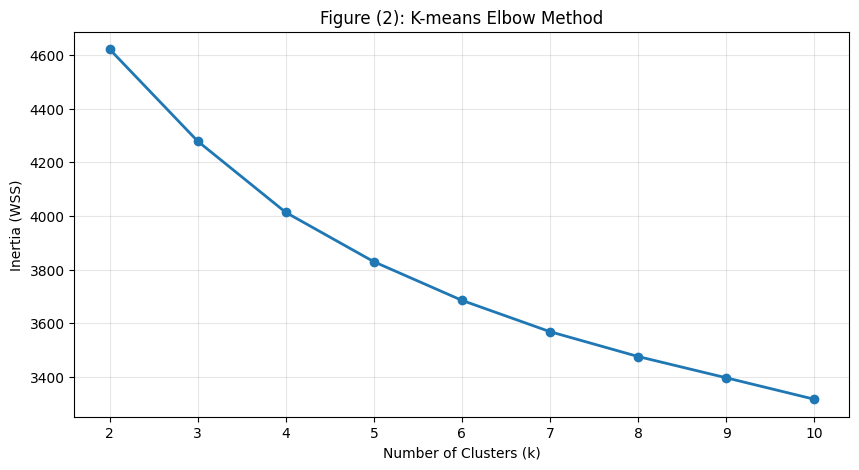

In [42]:
# Range of k values to test
k_range = range(2, 11)

# Store inertia (Within-Cluster Sum of Squares)
inertia = []

# Fit KMeans for each k and collect inertia
for k in k_range:
    model = KMeans(
        n_clusters=k,
        n_init=50,
        init='k-means++',
        random_state=42
    ).fit(clustering_data)
    
    inertia.append(model.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o', linestyle='-', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WSS)')
plt.title('Figure (2): K-means Elbow Method')
plt.grid(True, alpha=0.3)
plt.show()

As shown in figure (2), the Elbow curve exhibits a smooth and gradual decrease in clustering cost as the number of clusters increases, without a distinct point of sharp change in slope. Instead of forming a clear “elbow,” the curve follows a consistent downward trend, indicating that each additional cluster incrementally improves the model without a well-defined point of diminishing returns. This behavior suggests that the data does not contain well-separated groups, but rather exhibits continuous variation between observations. Therefore, relying solely on the Elbow Method is insufficient in this context, and additional validation techniques such as the Silhouette Score and the Davies-Bouldin Index are required to more reliably determine the optimal number of clusters.


#### **ii. Silhouette Score**

The Silhouette Score is primarily used to evaluate clustering quality by measuring how well each data point fits within its assigned cluster compared to other clusters. It provides a normalized score ranging from -1 to +1, capturing both intra-cluster cohesion and inter-cluster separation, making it a reliable indicator of how well-defined the clusters are.

Where:

- [+1] indicates that the sample is far from neighboring clusters and well matched to its assigned cluster.
- [0] indicates that the sample lies near the boundary between clusters.
- [-1] indicates that the sample may be misclassified.

#### **ii. Davies-Bouldin Index**

The Davies-Bouldin Index is primarily used to evaluate clustering quality by measuring the average similarity between clusters based on their compactness and separation. It reflects how distinct each cluster is from the others, with lower values indicating better-defined and more separated clusters.

Where:

- Lower values (closer to 0) indicate compact, well-separated clusters with minimal overlap.
- Higher values indicate that clusters are more similar to each other, suggesting poor separation and higher overlap.



While these metrics are primarily used to assess clustering quality, they can also support the selection of the optimal number of clusters (k) by comparing results across different values of k, where higher Silhouette scores and lower Davies-Bouldin values indicate better clustering performance.

In [18]:
# Store evaluation metrics
sil_scores = []
db_scores = []

# Compute metrics for each k
for k in k_range:
    model = KMeans(
        n_clusters=k,
        n_init=50,
        init='k-means++',
        random_state=42
    ).fit(clustering_data)
    
    labels = model.labels_
    
    # Silhouette: higher is better
    sil_scores.append(silhouette_score(clustering_data, labels))
    
    # Davies-Bouldin: lower is better
    db_scores.append(davies_bouldin_score(clustering_data, labels))

# Create results table
df_metrics = pd.DataFrame({
    'k': list(k_range),
    'Silhouette Score': sil_scores,
    'Davies-Bouldin': db_scores
})

# Highlight best values:
# Max Silhouette (best separation)
# Min Davies-Bouldin (least overlap)
display(
    df_metrics.head(9).style
    .background_gradient(subset=['Silhouette Score'], cmap='YlGn')
    .background_gradient(subset=['Davies-Bouldin'], cmap='YlOrRd_r') 
    .highlight_max(subset=['Silhouette Score'], color='lightgreen')
    .highlight_min(subset=['Davies-Bouldin'], color='lightgreen')
)

,k,Silhouette Score,Davies-Bouldin
0,2,0.178139,1.953387
1,3,0.127813,2.342360
2,4,0.106149,2.345041
3,5,0.102937,2.255907
4,6,0.098818,2.242694
5,7,0.090978,2.253228
6,8,0.090569,2.317315
7,9,0.088861,2.286075
8,10,0.087534,2.236626


*Table [1]: Silhouette Score & Davies-Bouldin Index for k-means clustering model with different k values*

Based on the evaluation results in in Table (1), the optimal number of clusters was selected by jointly considering the Silhouette Score and the Davies-Bouldin Index. The configuration with k = 2 achieved the highest Silhouette Score (0.178), Indicating relatively better separation and cohesion compared to other values. Additionally, it achieved the lowest Davies-Bouldin Index value (1.95), suggesting reduced overlap and more distinct clusters compared to other k configurations.

Although the Elbow Method was applied, it did not present a clear inflection point, making it insufficient as a standalone criterion. Therefore, greater reliance was placed on these two quantitative metrics, as they provide more direct and complementary insights into clustering quality. Based on their combined interpretation, **k = 2** was selected as the most appropriate clustering solution.

### 2.4 Applying clustering and assigning cluster labels


In [26]:
# Create a copy of the dataset
patient_data = clustering_data.copy()

# Set optimal number of clusters
k_optimal = 2

# Initialize the model
kmeans_final = KMeans(
    n_clusters=k_optimal,
    random_state=42,
    init='k-means++',
    n_init=50
)

# Fit the model and predict cluster labels
clusters = kmeans_final.fit_predict(clustering_data)

# Assign cluster labels to the copied dataset
patient_data['cluster'] = clusters

# Save to CSV
patient_data.to_csv('Dataset/kmeans_clustered_data.csv', index=False)

---

## **Section 3. Evaluation Metrics & Visualizations**

### **3.1 Evaluation Metrics**

In this section, we briefly revisit the evaluation metrics introduced in Section 3 and apply them to assess the clustering results.

**i. WCSS (Within-Cluster Sum of Squares)** Used within the Elbow Method to analyze cluster compactness and observe how clustering cost decreases as k increases.

**ii. Silhouette Score** Used to evaluate how well-separated and cohesive the clusters are, providing insight into the quality of cluster assignments.

**iii. Davies-Bouldin Index** Used as a complementary measure to assess cluster separation and overlap, where lower values indicate better-defined clusters.


In [28]:
# Using our final model labels
labels = clusters

# Compute metrics
silhouette = silhouette_score(clustering_data, labels)
db_index = davies_bouldin_score(clustering_data, labels)
wcss = kmeans_final.inertia_

# Create a single-row table
evaluation_df = pd.DataFrame([{
    'k': 2,
    'Silhouette Score': f"{silhouette:.3f}",
    'Davies-Bouldin Index': f"{db_index:.3f}",
    'WCSS': f"{wcss:.3f}"
}])

# Save to CSV
evaluation_df.to_csv('Unsupervised_Learning/clustering_results/evaluations/k-means_metrics.csv', index=False)

# Display
evaluation_df


,k,Silhouette Score,Davies-Bouldin Index,WCSS
0,2,0.178,1.953,4621.084


*Table [2]: Evaluation metrics for the k-means clustering model (k = 2), including Silhouette Score, Davies–Bouldin Index, and WCSS.*

**The Silhouette Score**, being (0.178) close to zero, indicates that the clusters are not well separated and that there is considerable overlap between neighboring data points. While this is typically interpreted as poor clustering performance, it is important to contextualize this result within the domain of medical data. In such datasets, patient characteristics often exist along continuous spectra rather than forming clearly distinct groups, meaning that strict cluster boundaries are rarely present. Therefore, some degree of overlap is expected and does not necessarily invalidate the usefulness of the clustering. Despite the low silhouette score, the resulting clusters can still provide practical value. Rather than representing sharply defined categories, they can be interpreted as grouping patients with broadly similar risk profiles or clinical patterns. This makes the clustering useful for exploratory analysis and subgroup identification, even if it is not suitable for definitive classification or diagnosis.

**The Davies–Bouldin Index** of (1.953) further supports the observation of weak clustering quality. A higher value indicates that clusters are less compact and less well separated from each other, suggesting that intra-cluster similarity is relatively low compared to inter-cluster similarity. This implies that many patients lie near the boundaries of their assigned clusters while still sharing similarities with patients in neighboring clusters. Such behavior is reasonable in the context of medical data, where patient conditions and risk factors often overlap and evolve along continuous spectra, This behavior is consistent with real-world healthcare data, where heterogeneity and gradual transitions between patient states limit the formation of well-separated clusters. 

**The Within-Cluster Sum of Squares** (WCSS) value of 4621.084 represents the total variance within the clusters, indicating how closely data points are grouped around their respective cluster centroids. Lower WCSS values generally correspond to more compact clusters

Medical datasets frequently exhibit low silhouette scores due to overlapping patient characteristics and continuous variation in clinical features. This behavior has been widely observed in the literature, where clustering is used to identify patient subgroups or phenotypes rather than strictly separable classes. For example, studies such as Ahlqvist et al. (2018) on diabetes subtypes and Seymour et al. (2019) on sepsis phenotyping demonstrate that clinically meaningful clusters can still be identified despite overlap and weak separation. These findings reinforce that, in medical contexts, clustering results should be interpreted as approximate groupings that support risk stratification and exploratory analysis rather than definitive classifications.

> Ahlqvist, E., Storm, P., Käräjämäki, A., et al. (2018).  
   *Novel subgroups of adult-onset diabetes and their association with outcomes: a data-driven cluster analysis.*  
   The Lancet Diabetes & Endocrinology, 6(5), 361–369.  
   https://doi.org/10.1016/S2213-8587(18)30051-2  
>
> Seymour, C. W., Kennedy, J. N., Wang, S., et al. (2019).  
   *Derivation, validation, and potential treatment implications of novel clinical phenotypes for sepsis.*  
   JAMA, 321(20), 2003–2017.  
   https://doi.org/10.1001/jama.2019.5791  
>
> Shah, S. J., Katz, D. H., Selvaraj, S., et al. (2015).  
   *Phenomapping for novel classification of heart failure with preserved ejection fraction.*  
   Circulation, 131(3), 269–279.  
   https://doi.org/10.1161/CIRCULATIONAHA.114.010637  

**iiii. Precision & Recall**

When ground truth labels are available, clustering performance can be evaluated using classification-based metrics such as Precision and Recall. These metrics assess how well the predicted cluster assignments align with the true labels.

**Precision** measures the proportion of correctly assigned data points within a cluster relative to all points assigned to that cluster. It reflects the accuracy of positive predictions.

**Recall** measures the proportion of correctly assigned data points within a cluster relative to all actual points belonging to that class in the ground truth. It reflects the model’s ability to capture all relevant instances.

Before evaluating the clustering results using classification metrics, it is necessary to align the cluster labels with the true labels. Since clustering is an unsupervised learning technique, the generated cluster labels do not directly correspond to the actual class labels. To address this, a mapping process is applied where each cluster is assigned to the most frequent true label within that cluster. This approach, known as majority voting, allows us to convert cluster assignments into predicted labels that can be compared with the ground truth. Once this mapping is established, standard evaluation metrics such as precision and recall can be computed.

In [31]:
mapping = {}

for c in set(clusters):
    mask = (clusters == c)
    majority_label = original_data[mask]["HeartDisease"].mode()[0]
    mapping[c] = majority_label
    
# True labels (ground truth)
true_labels = original_data["HeartDisease"]

# Predicted (after mapping)
predicted_labels = [mapping[c] for c in clusters]

# Get report as dict
report = classification_report(true_labels, predicted_labels, output_dict=True)

# Extract only precision & recall
pr_df = pd.DataFrame(report).transpose()[['precision', 'recall']]

# Keep only class rows (0 and 1)
pr_df = pr_df.loc[['0', '1']]

# Rename for readability
pr_df.index = ['No Disease (0)', 'Disease (1)']

# Display
display(
    pr_df.style
    .set_caption("K-means Precision & Recall")
    .format("{:.3f}")
    .background_gradient(cmap='YlGn')
)

pr_df.to_csv('Unsupervised_Learning/clustering_results/evaluations/k-means_precision_recall.csv', index=True)

,precision,recall
No Disease (0),0.731,0.761
Disease (1),0.800,0.773


*Table [3]: Precision and Recall for K-Means (k = 2) compared against ground truth labels (0 = No Disease, 1 = Disease)*

The results show that the clustering-based predictions achieve reasonable alignment with the ground truth labels. For the disease class (1), the model attains a precision of 0.800, indicating that 80% of patients identified as having the disease are correctly classified. The recall of 0.773 further suggests that a large proportion of actual disease cases are successfully captured by the clustering structure.

For the no disease class (0), the model achieves a precision of 0.731 and a recall of 0.761, reflecting slightly lower but still consistent performance. This indicates that the model is moderately effective in identifying healthy individuals, though with some overlap between clusters. Overall, these results suggest that the clustering approach is able to uncover meaningful patterns in the data that align with clinical outcomes, particularly in identifying disease cases. However, the moderate scores across both classes also highlight some degree of overlap between patient groups, which is expected given the continuous nature of medical features.

### **3.2 Visualizations**

Most datasets contain many variables resulting in large dimensional space, making it impossible to see how points relate to one another in their raw state. By reducing the complexity of the data while preserving as much of the original variance in the structure as possible. This helps us verify that the clusters are distinct and provides a visual sanity check for the results of the clustering algorithm.

#### **i. Principal Component Analysis (PCA)**

PCA follows a specific linear transformation process, It aims to maximize the variance where it ensures that you squeeze the data into a 2D or 3D view while losing as little information as possible. Bt Projecting data onto a lower-dimensional subspace and identifying the principal components (the directions where the data is most spread out). These directions are found by calculating the act as the possible "angles" or directions to view the data (known as eigenvectors) and which "angle" shows the most spread (eigenvalues) of the covariance matrix. The eigenvectors with the largest eigenvalues are selected as the principal components. By using these as our axes (e.g., X and Y), we effectively capture the most significant patterns in the data.

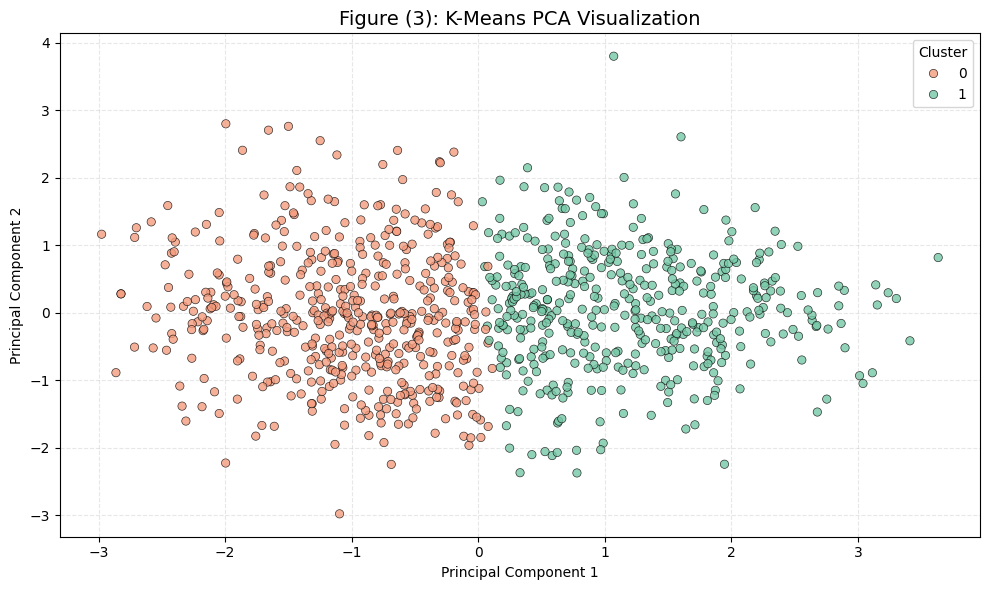

In [43]:
# PCA Transformation
pca = PCA(
    n_components=2,  # Reduce to 2 components for visualization
    random_state=42  # Ensure reproducibility
)

pca_components = pca.fit_transform(clustering_data)

# Store temporarily for plotting
plot_df = patient_data.copy()
plot_df['pca_1'] = pca_components[:, 0]
plot_df['pca_2'] = pca_components[:, 1]

# Plot
plt.figure(figsize=(10, 6))


# Colors
color_map = {
    0: "#f69c7e",   
    1: "#76c8a7",  
}

sns.scatterplot(
    x='pca_1',
    y='pca_2',
    hue='cluster',
    data=plot_df,
    palette=color_map,
    edgecolor='black',
    alpha=0.8
)

plt.title('Figure (3): K-Means PCA Visualization', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

As shown in Figure (3), the PCA visualization reveals a clear directional separation between the two clusters, primarily along the first principal component. This suggests that an underlying global structure exists in the data, even though some overlap is present.

However, the relatively low Silhouette Score (≈ 0.178) indicates weak overall cluster separation, highlighting that this visual split does not fully translate into well-defined boundaries. At the same time, the relatively strong precision and recall scores (≈ 0.7 - 0.8 ), along with a moderate Davies-Bouldin Index (≈ 1.9), indicate that the clusters still capture meaningful patterns aligned with the underlying labels. This suggests that, while the clusters are not tightly compact or fully separated, they remain sufficiently informative for distinguishing between patient groups.

Overall, PCA highlights global separability, whereas the evaluation metrics reveal local overlap, demonstrating a trade-off that is common in complex medical datasets where patterns are not strictly distinct.

#### **ii. T-distributed Stochastic Neighbor Embedding (t-SNE)** 

t-SNE is a non-linear dimensionality reduction technique designed to capture the local structure of high-dimensional data. It works by converting pairwise Euclidean distances between data points into joint probability distributions, representing similarities in the high-dimensional space. It then maps the data into a lower-dimensional space by minimizing the Kullback–Leibler (KL), which means it tries to make the new representation preserve the same similarities between data points as in the original space. This process preserves local relationships, making t-SNE particularly effective for visualizing clusters and complex non-linear patterns. Unlike PCA, which is a linear technique that projects data onto directions of maximum variance, t-SNE focuses on preserving local neighborhood structures rather than global variance. As a result, PCA provides a more stable and interpretable transformation, while t-SNE offers better visualization of non-linear cluster structures.

However, t-SNE is a stochastic algorithm, meaning that results can vary between runs unless a random seed is fixed. It is also sensitive to hyperparameters such as perplexity and learning rate, which can significantly affect the output. Additionally, t-SNE does not preserve global distances, making it unsuitable for measuring true relationships between clusters. It is primarily a visualization tool and should not be used for downstream tasks such as clustering or feature importance analysis.

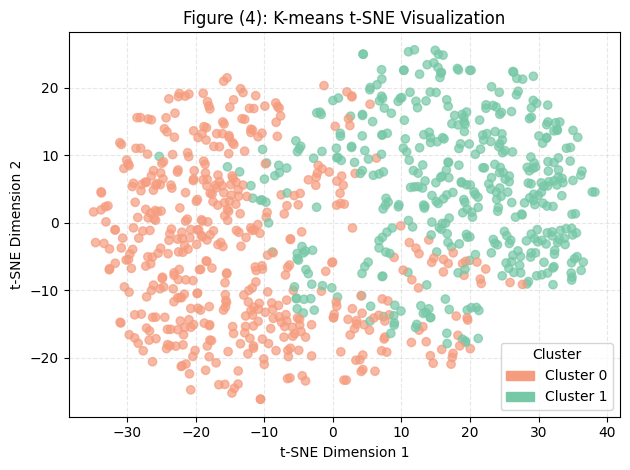

In [44]:
tsne = TSNE(
    n_components=2,          # Better for binary-heavy data visualization
    perplexity=40,           # Balanced for ~900 samples
    learning_rate='auto',    # Keeps the optimization stable
    max_iter=1000,           # Number of optimization iterations (ensures convergence)
    random_state=42          # Ensure reproducibility
)

X_tsne = tsne.fit_transform(clustering_data)

# Using existing color_map 
colors = [color_map[c] for c in clusters]

# Plot
plt.figure()
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, alpha=0.7)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("Figure (4): K-means t-SNE Visualization")

# Legend (reuse color_map)
handles = [
    mpatches.Patch(color=color_map[i], label=f'Cluster {i}')
    for i in sorted(color_map.keys())
]

plt.legend(handles=handles, title="Cluster")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

As shown in Figure (4), Cluster 1 exhibits a noticeable degree of overlap with Cluster 0, with many of its data points extending into regions dominated by Cluster 0. This indicates the presence of shared patterns between the two groups, where patients assigned to different clusters exhibit similar feature profiles.

Such overlap suggests that there is no clear boundary between disease and non-disease cases, reflecting the inherent complexity of medical data. In particular, it highlights that certain patients may display characteristics of both groups, leading to ambiguity in cluster assignment. This observation further explains the moderate precision and recall scores (≈ 0.7 - 0.8), as overlapping regions increase the likelihood of incorrect cluster assignment between disease and non-disease cases. It is also consistent with the low Silhouette Score (≈ 0.178), which indicates the absence of clear boundaries between clusters and reflects weak overall separation.

### **3.3 Feature Importance Per Cluster**

Feature importance refers to identifying and ranking the features that most influence a model’s behavior. In clustering, it aims to determine which variables most influence the formation and differentiation of clusters, despite the absence of true labels. 

#### **i. standardized centroid deviation**

To interpret the clusters generated by K-Means, a centroid-based approach was adopted, using standardized centroid deviation, where the difference between each cluster centroid and the global dataset mean was normalized by the feature’s standard deviation. This provides a scale-independent measure of how strongly each feature differentiates a cluster from the overall data distribution. Since each centroid represents the mean profile of its cluster (MacQueen, 1967), features with larger standardized deviations indicate stronger contribution to defining the cluster. These features correspond to dimensions along which the cluster is most distinct relative to the dataset. This provides a fully unsupervised and interpretable method for estimating feature importance, as it relies directly on centroid representations without requiring external models.

> https://medium.com/%40a.cervantes2012/interpreting-and-validating-clustering-results-with-k-means-e98227183a4d?utm_source=chatgpt.com "Interpreting and Validating Clustering Results with K-Means"


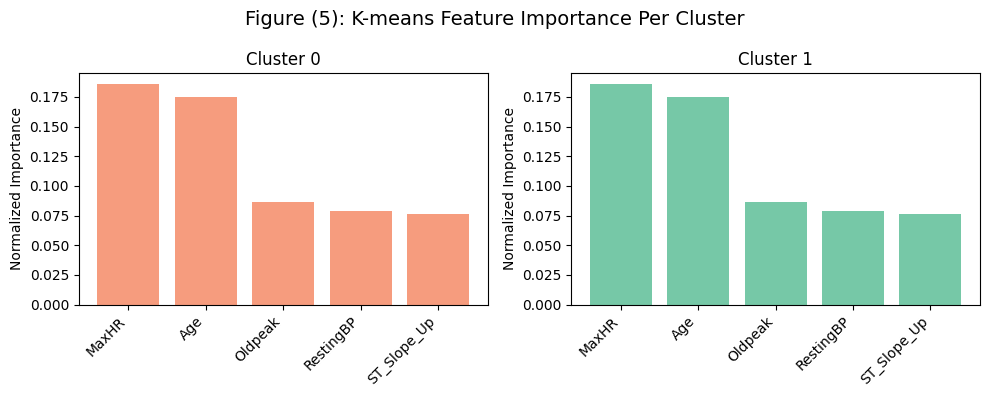

In [45]:
# Centroid-Based Feature Importance (Normalized Deviation)
# Convert dataset to NumPy array for numerical operations
X_values = clustering_data.values

# Extract final cluster centroids from the trained K-Means model
final_centroids = kmeans_final.cluster_centers_

# Compute the global mean of the dataset (reference point)
global_mean = np.mean(X_values, axis=0)

# Compute absolute deviation of each centroid from the global mean
# This measures how much each cluster differs from the overall dataset per feature
abs_movement = np.abs(final_centroids - global_mean)

# Get feature names (handles both DataFrame and NumPy cases)
feature_names = clustering_data.columns if hasattr(clustering_data, "columns") else [f"Feature {i}" for i in range(clustering_data.shape[1])]

# Dictionary to store feature importance per cluster
feature_importance = {}

# Loop over each cluster
for i in range(k_optimal):
    # Get deviation values for current cluster
    vals = abs_movement[i]
    
    # Normalize values so they sum to 1 (relative importance)
    vals_norm = vals / vals.sum()
    
    # Sort features by importance (descending order)
    sorted_idx = np.argsort(vals_norm)[::-1]

    # Store sorted feature importance as (feature_name, importance_score)
    feature_importance[i] = [
        (feature_names[j], vals_norm[j]) for j in sorted_idx
    ]

k = k_optimal # Number of clusters
top_n = 5 # Number of top features to display per cluster

# Create subplots (1 row, k columns)
fig, axes = plt.subplots(1, k, figsize=(5*k, 4))
warnings.filterwarnings("ignore")

# Plot each cluster in its subplot
for i, ax in enumerate(axes):
    features, values = zip(*feature_importance[i][:top_n])
    
    ax.bar(features, values, color=color_map.get(i))
    ax.set_title(f"Cluster {i}")
    ax.set_xticklabels(features, rotation=45, ha='right')
    ax.set_ylabel("Normalized Importance")


fig.suptitle("Figure (5): K-means Feature Importance Per Cluster", fontsize=14)

plt.tight_layout()
plt.show()

Across both clusters, the most consistently influential features are MaxHR, Age, Oldpeak, ST_Slope, and RestingBP, as they repeatedly appear among the top-ranked variables. This indicates that these features form the core dimensions along which the clusters are differentiated.

 **Cluster 0** is primarily characterized by MaxHR and Age, indicating that variations in maximum heart rate and age play a major role in defining this group. Additional contributions from Oldpeak, ST_Slope, and RestingBP suggest that multiple cardiovascular indicators collectively shape the cluster profile.

 **Cluster 1** is influenced by a very similar set of features, particularly MaxHR and Age, with secondary contributions from Oldpeak, ST_Slope, and RestingBP. The similarity in feature importance across both clusters indicates that the distinction between them is not based on different variables, but rather on differences in the values of these shared features.

Overall, the dominance of MaxHR, Age, Oldpeak, and RestingBP suggests that the clustering structure is primarily driven by continuous physiological variables. The similarity in feature importance across clusters further indicates that the dataset does not contain entirely distinct subgroups defined by different attributes, but rather reflects gradual variation along the same key clinical dimensions. This is consistent with the weak but observable clustering structure identified earlier

### **3.4 Cluster size distribution**

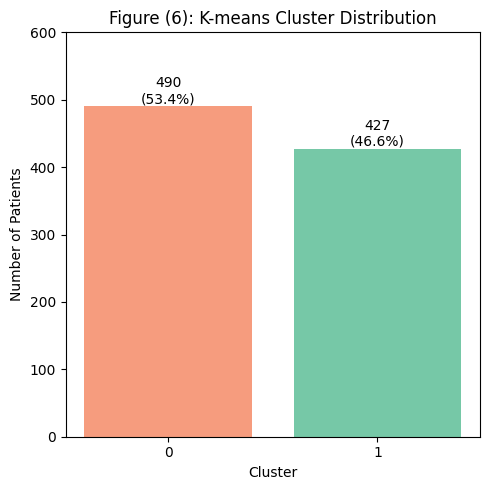

In [46]:
# Count samples per cluster
cluster_counts = patient_data['cluster'].value_counts().sort_index()

# Total samples
total = len(patient_data)

# Using our predefined color_map
colors = [color_map[i] for i in cluster_counts.index]

# Plot
plt.figure(figsize=(5, 5))
bars = plt.bar(cluster_counts.index, cluster_counts.values, color=colors)

# Titles and labels
plt.title('Figure (6): K-means Cluster Distribution')
plt.xlabel('Cluster')
plt.ylabel('Number of Patients')
plt.ylim(0, 600)

# Add values and percentages on bars
for i, count in enumerate(cluster_counts.values):
    percentage = (count / total) * 100
    plt.text(i, count, f'{count}\n({percentage:.1f}%)',
             ha='center', va='bottom')

plt.xticks(cluster_counts.index)
plt.tight_layout()
plt.show()

The cluster distribution shown in figure (6) reveals a relatively balanced split between the two clusters, with approximately 46% and 53% of the samples assigned to Cluster 0 and Cluster 1, respectively. Interestingly, this distribution closely aligns with the original class distribution of the dataset, where patients were labeled as either having heart disease or not. Although the clustering process was performed in an unsupervised manner without using the target variable, the similarity in proportions suggests that the model has successfully captured an underlying structure consistent with the true data distribution. This alignment provides additional support for the validity of the clustering results, indicating that the identified clusters are not arbitrary but reflect meaningful patterns inherent in the dataset.

---

## **Section 4. Cluster Interpretation & Profiles**

## **4.1 Cluster Profiles**

Cluster profiling is the process of translating the mathematical centers (centroids) of each group into descriptive human personas. By analyzing the mean values of features within each segment, we can identify the specific personality of a cluster determining which traits are dominant, which are rare, and how each group deviates from the population average. This step moves beyond simple grouping to explain the clinical and demographic logic behind why these specific individuals were clustered together, transforming raw data into identifiable segments. For continuous variables, the cluster means are interpreted relative to the dataset average, allowing us to describe whether a feature is higher or lower compared to the general population. In contrast, for binary (0/1) encoded variables, the mean directly represents the proportion of individuals within the cluster exhibiting that characteristic, enabling interpretation in terms of percentages.

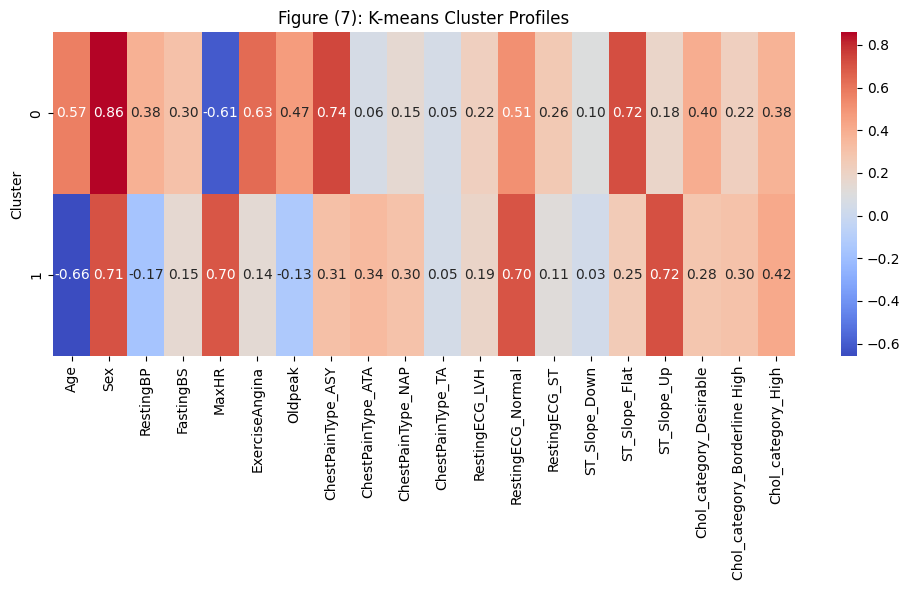

In [47]:
# Compute mean values of features for each cluster
cluster_profiles = patient_data.groupby('cluster').mean()

# Display the profiles
cluster_profiles

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profiles, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Figure (7): K-means Cluster Profiles")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

#### **Cluster 0 Interpretation: High Cardiovascular Risk Profile**

Cluster 0 represents a group of relatively older individuals, with an average age above the dataset mean (53 years). This cluster is predominantly male, with approximately 86% males and only 13% females. However, this imbalance is influenced by the dataset’s overall gender distribution, where nearly 79% of the individuals are male. Therefore, the male dominance in this cluster is heavily influenced by the dataset distribution.

In terms of resting blood pressure (RestingBP), individuals in this cluster exhibit values higher than the dataset average (above 132), suggesting a tendency toward elevated blood pressure levels. Clinically, higher resting blood pressure is associated with increased cardiovascular strain and is considered a known risk factor for hypertension and coronary artery disease. Regarding fasting blood sugar (FastingBS), only 30% of individuals have values above 120, indicating that the majority maintain normal glucose levels. This suggests that, while blood pressure may contribute to cardiovascular risk in this cluster, impaired glucose regulation appears less prominent.

This cluster is also characterized by lower maximum heart rate values (below 136), suggesting reduced cardiovascular performance compared to the dataset average. Additionally, individuals in this cluster show higher Oldpeak values (above 0.88), which represent ST-segment depression during exercise. Elevated Oldpeak values are associated with reduced coronary blood flow and may indicate the presence of coronary artery disease.

Furthermore, 63% of individuals in this cluster exhibit exercise-induced angina (ExerciseAngina), which refers to chest pain triggered by physical exertion due to insufficient blood supply to the heart.

Regarding chest pain types, the dominant category in this cluster is asymptomatic (ASY), with 74% of individuals. This indicates that a large proportion of patients do not experience chest pain despite potential underlying heart disease. This is followed by atypical angina (ATA) at 15%, while non-anginal pain (NAP) and typical angina (TA) are less represented. This distribution is partially influenced by the dataset proportions, where NAP and TA are less frequent overall.

For resting ECG results, 50% of individuals show normal readings. The remaining individuals exhibit abnormalities, including left ventricular hypertrophy (LVH) at 22% and ST-T wave abnormalities (ST) at 26%. These conditions may indicate structural or electrical heart abnormalities, such as myocardial ischemia or chronic hypertension.

In terms of ST slope during exercise, the majority being 70% exhibit a flat slope, which is commonly associated with myocardial ischemia. Only 18% show an upsloping pattern, typically considered normal, while approximately 10% show a downsloping pattern, which may indicate more severe cardiac conditions. The low percentage of downsloping cases may also reflect its low prevalence in the dataset.

Finally, cholesterol levels in this cluster show a mixed distribution across categories. The desirable range represents the largest proportion (40%), followed by the high category (38%), while the borderline group accounts for 22%. This indicates that, although the majority of individuals fall within the normal cholesterol range, a nearly comparable proportion exhibit elevated cholesterol levels. This pattern reflects heterogeneity within the cluster, where individuals share similar overall cardiovascular characteristics but differ in lipid levels. Clinically, this suggests that while the cluster is not uniformly at high lipid risk, a substantial proportion of individuals may still be at increased risk of atherosclerosis and coronary artery disease.

Overall, Cluster 0 can be characterized as a group of older individuals, predominantly male, with higher resting blood pressure and reduced cardiovascular performance, as reflected by lower maximum heart rate values. This cluster also exhibits multiple indicators associated with increased cardiovascular risk, including elevated Oldpeak values, a high prevalence of exercise-induced angina, and predominantly abnormal ST slope patterns, suggesting a higher likelihood of ischemic abnormalities.

#### **Cluster 1 Interpretation: Lower Cardiovascular Risk with Emerging Metabolic Risk**

Cluster 1 represents a group of relatively younger individuals, with an average age below the dataset mean (53 years), but not lower than 27 years. Similar to Cluster 0, this cluster is predominantly male, though slightly less extreme. However, this pattern is influenced by the dataset’s overall male dominance.

In terms of resting blood pressure (RestingBP), individuals in this cluster exhibit values slightly (below 132) compared to the dataset average, suggesting generally normal or mildly lower blood pressure levels. Regarding fasting blood sugar (FastingBS), only a small proportion (around 15%) have elevated levels (>120), indicating that the majority of individuals maintain normal glucose levels.

This cluster is also characterized by higher maximum heart rate values (above 136), indicating better cardiovascular performance compared to the dataset average. Additionally, individuals in this cluster show lower Oldpeak values (below 0.88), reflecting minimal ST-segment depression during exercise. Lower Oldpeak values are typically associated with better coronary blood flow and a reduced likelihood of ischemia.

Furthermore, exercise-induced angina (ExerciseAngina) appears less prominent in this cluster, with only around 14% of individuals experiencing chest pain during physical exertion.

Regarding chest pain types, this cluster shows a partially distributed pattern rather than a fully balanced one. Atypical angina (ATA) represents the highest proportion (34%), followed by asymptomatic cases (31%) and non-anginal pain (30%), which appear at similar levels. In contrast, typical angina (TA) is minimally represented (5%), indicating a clear underrepresentation compared to other categories. This suggests that while most chest pain types are similarly distributed, typical angina is not a defining feature of this cluster. Clinically, chest pain is known to be heterogeneous, where conditions such as coronary artery disease may present as typical, atypical, or even asymptomatic (European Society of Cardiology, 2019). Therefore, the low representation of typical angina alongside higher proportions of atypical and asymptomatic cases suggests that this cluster is not defined by classical symptom presentation, but rather by underlying physiological patterns.

For resting ECG results, normal readings are more prominent in this cluster, with approximately 70% of individuals showing normal ECG patterns, indicating generally healthier cardiac electrical activity. Abnormalities such as left ventricular hypertrophy (LVH) and ST-T wave changes are less pronounced, accounting for approximately 19% and 11%, respectively.

In terms of ST slope during exercise, the upsloping pattern is dominant, observed in approximately 72% of individuals, which is typically considered a normal response. Flat slopes are present but less dominant (around 25%), while downsloping patterns remain minimal. However, this may be partially influenced by the dataset distribution, where downsloping cases are generally less common.

Finally, cholesterol levels in this cluster show a proportional shift toward higher categories. The high cholesterol group represents the largest proportion (42%), followed by the borderline category (30%), while the desirable category accounts for the smallest proportion (28%). This distribution indicates that a greater share of individuals fall within elevated cholesterol ranges. Clinically, this pattern suggests an increased likelihood of lipid-related cardiovascular risk, as a higher proportion of individuals with elevated cholesterol is associated with a greater risk of atherosclerosis and coronary artery disease.

Overall, Cluster 1 can be characterized as a group of younger individuals with better cardiovascular performance, lower Oldpeak values, and generally normal ECG and ST slope patterns, indicating a lower likelihood of ischemic abnormalities. However, despite these favorable cardiac indicators, the distribution of cholesterol levels shows a noticeable shift toward elevated categories. This suggests that, while the cluster is functionally healthier from a cardiovascular perspective, there is an emerging metabolic risk that may contribute to future cardiovascular complications.

> European Society of Cardiology (2019). 2019 ESC Guidelines for the diagnosis and management of chronic coronary syndromes. European Heart Journal. Available at: https://www.escardio.org

## 4.2 Domain Relation

Cluster 0 demonstrates a strong alignment with high cardiovascular risk profiles. The combination of higher Oldpeak values, lower maximum heart rate, and a high proportion of exercise-induced angina , along with predominantly flat ST slope patterns, is clinically associated with myocardial ischemia and reduced coronary blood flow (European Society of Cardiology, 2019). Additionally, the dominance of asymptomatic chest pain suggests the presence of underlying cardiac conditions that may not be immediately apparent through symptoms alone. These findings are consistent with established cardiovascular knowledge, where ST-segment depression, exercise-induced angina, and abnormal ST slope patterns are recognized indicators of coronary artery disease (European Society of Cardiology, 2019). If integrated into an advice system, this cluster would represent a high-risk group that would require more cautious and targeted recommendations, with a focus on risk awareness and early identification of potential cardiovascular conditions.

In contrast, Cluster 1 reflects a comparatively lower cardiovascular risk profile. This cluster is characterized by higher maximum heart rate, lower Oldpeak values, and a predominance of normal ST slope patterns, which are typically associated with a normal cardiac response to exercise (European Society of Cardiology, 2019). Furthermore, the lower proportion of exercise-induced angina supports the interpretation of better cardiovascular function. However, the higher proportion of individuals with elevated cholesterol levels (42% in the high category) suggests a potential underlying metabolic risk that may contribute to future cardiovascular complications. If applied within an advice system, this cluster would represent a lower-risk group where recommendations would focus on maintaining cardiovascular health while addressing potential metabolic risk factors to prevent future progression.

Overall, the consistency between the data-driven clustering results and established clinical patterns supports the validity and interpretability of the model. These findings indicate that the clustering approach successfully captures meaningful patient subgroups. These groups could be utilized to support personalized recommendations if feasible.

> European Society of Cardiology (2019). 2019 ESC Guidelines for the diagnosis and management of chronic coronary syndromes. European Heart Journal. Available at: https://www.escardio.org

--- 



## **Section 5. Integration Feasibility and Justification**

While k-means clustering was explored and implemented, it was not selected for direct integration into the advice system. This decision is primarily due to the supervised learning approach adopted in Phase 1, which provided more reliable and interpretable predictions where it is considered as an essential requirement for a generative AI-based medical advice system. In contrast, the clustering results showed limited separation between groups and significant overlap in patient characteristics, as discussed in Section [4], making them less suitable for precise decision-making or user-facing recommendations.

However, this does not render the clustering model without value. The clustering component can serve as a supplementary feature to enhance the contextual understanding of the generative AI advice system. For instance, cluster membership may be incorporated as an additional input to guide more personalized and context-aware advice generation, complementing the predictions derived from the supervised learning model. However, given the relatively low silhouette score, the clustering structure should be interpreted with caution and used only as a weak contextual signal rather than a definitive grouping. This approach is consistent with established practices in machine learning, where unsupervised techniques are used for feature enrichment and to provide additional structure to downstream models (Bengio et al., 2013).

> Bengio, Y., Courville, A., & Vincent, P. (2013). *Representation Learning: A Review and New Perspectives*. IEEE Transactions on Pattern Analysis and Machine Intelligence, 35(8), 1798–1828.

----

## **Section 6. Challenges & Limitations**

The application of k-means clustering to the heart disease dataset revealed three key challenges. First, as illustrated in Figure 1, determining the optimal number of clusters (k) was ambiguous, as the elbow point was not clearly identifiable, introducing uncertainty into the model selection process. Second, the dataset exhibited significant overlap in patient characteristics, reflecting the continuous nature of cardiovascular risk, which resulted in weak separation between clusters as observed in visualizations using Principal Component Analysis and t-distributed Stochastic Neighbor Embedding. Third, interpreting the resulting cluster profiles posed a challenge, as translating statistical feature averages into meaningful medical insights required additional domain understanding and research. Together, these challenges highlight both the methodological limitations of k-means and the complexity of working with real-world clinical data, suggesting that future work may benefit from alternative clustering approaches or enhanced feature engineering techniques.

The application of k-means clustering to the heart disease dataset revealed three key challenges. First, as illustrated in figure 2, determining the optimal number of clusters (k) was ambiguous, as the elbow point was not clearly identifiable, introducing uncertainty into the model selection process. Second, the dataset exhibited significant overlap in patient characteristics, reflecting the continuous nature of cardiovascular risk, which resulted in weak separation between clusters, as observed in visualizations using Principal Component Analysis and t-distributed Stochastic Neighbor Embedding of figures (3) and (4) . Third, interpreting the resulting cluster profiles posed a challenge, as translating statistical feature averages into meaningful medical insights required additional domain understanding and research.

In addition, these observations highlight a broader limitation related to data suitability for clustering. When a dataset does not exhibit clear separability, clustering techniques may not yield well-defined groups. This underscores the importance of evaluating alternative datasets or feature representations when clustering performance is limited. In this work, the dataset was primarily used for exploratory and educational purposes, which provided valuable insights into both the capabilities and limitations of clustering methods when applied to real-world clinical data.

Together, these challenges emphasize both the methodological limitations of k-means and the inherent complexity of real-world medical datasets, suggesting that future work may benefit from alternative clustering approaches or enhanced feature engineering techniques.

---

## **Cluatering Model 2: HDBSCAN**

## Section 1. Clustering Rationale & Algorithm Selection

### **What is HDBSCAN Algorithm?**

HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise) is a clustering algorithm that builds a hierarchy of clusters based on density. It is an extension of the DBSCAN method, which is a density-based clustering method. However, DBSCAN struggles with the assumption of global density, meaning it uses the same density threshold for all clusters. This often does not comply with medical datasets or many real world datasets in general , where clusters may have varying densities and sizes. Unlike DBSCAN, HDBSCAN can identify these variations effectively.

One of the most interesting features of the HDBSCAN algorithm is its ability to decide the optimal number of clusters while remaining robust to noise and outliers. These outliers are prevalent in our medical dataset and cannot be ignored, as they may represent significant clinical cases. This process of selecting the appropriate number of clusters is handled systematically by examining cluster stability across various density thresholds.


### **How does it work?**

The HDBSCAN algorithm consist of two phases:

- ***Mutual Reachability Graph***\
The algorithm starts by computing the core distance $d_c$ for all points. This represents the distance between a point $x_p$ and its $n$-th nearest neighbor $x_{s}, where $n$ is defined by the `min_samples` parameter. The smaller core distance the more points near to it the more density spot the point in. It calculated by the following formula:  $$d_c(x_p) = d(x_p, x_s)$$\
Then it calculates the mutual reachability distance $d_m$ between every pair points using the following formula: $$d_m(x_p, x_q) = \max \{d_c(x_p), d_c(x_q), d(x_p, x_q)\}$$ By taking the maximum, the algorithm effectively spreads out points that are in sparse regions.Thus, even if two points are close to each other. if one of them is in a low-density spot (large $d_c$), the mutual reachability distance between them will be larger. This gives a small distance between points that are both close to each other and located in high-density regions.\
After the computing mutual reachability distances, the algorithm builds the mutual reachability graph $G_{ms}$, where each data point represented as a vertex, and the edges between points represent the mutual reachability distance between them.

- ***Hierarchical Clustering***\
As we mentioned before, the HDBSCAN finds the appropriate number of clusters by examining clusters stability across various density thresholds **$\epsilon$**. This gives all connected parts for all **$\epsilon$** values. This done as the following:
1. Extracting a minimum spanning tree (MST) of $G_{ms}$, that is the subset of edges that connects all vertices together, without any cycles, and with the minimum possible total edge weight.
2. Adding a "self edge" for each vertex on the MST with a weight equals to its core distance.
3. Create a single cluster that contains the whole MST.
4. Finding the edges with the greatest weight (core distance) and remove them to splits the vertex groups connected with a weak edge, generating two **connected components**.
5. Labeling the connected components (clusters).
    1. If a connected component contains only one vertex (no edge) or less than `min_cluster_size` parameter if specified, label it as null (noise).
    2. If a connected component contains more than one vertex label it as a new cluster.
6. Repeat 4-5 until there are no more connected components (clusters become stable).

### **Why is HDBSCAN suitable for our data?**

#### i. Dataset size & feature types

The HDBSCAN algorithm affected by high-dimensional spaces (50-100 features) and can result in curse of dimensionality unless dimensionality reduction techniques applied [-], however our dataset were shrink after performing multiple experiments by researchers to includes only the top 20 important features as their consequences (other illnesses) affects the heart disease [-]. Consequently, dimensionality is not a concern, as 20 features does not considered high-dimensional and as our sample size ($N = 917$) exceeds the recommended 10–20 times the number of features.

It is also capable of handling mixed data types including both continuos and categorical features as long as the categorical features are appropriately preprocessed (e.g., One-Hot Encoding for nominal data and Label Encoding for ordinal data). Our preprocessing pipeline has already addressed these requirements, making HDBSCAN suited for our dataset.

The HDBSCAN algorithm considered a good choice for complex datasets like our medical dataset, as it is able to handle sparse clusters with varying shapes and densities of patients. These variations results from the various combinations of features that leads to herat disease and other diseases that can result from those combinations and cause a heart disease, some of those caused combinations have a high density ( combinations associated with high occurrence heart disease cause like Diabetes) others can have low density ( unpopular heart disease causes and conditions), the HDBSCAN can handle this density variation problem and not only specify a single density threshold.

---

#### ii. Expected cluster shapes

---

#### iii. Scalability & interpretability

- **Scalability** \
In the theoretical explanation of HDBSCAN algorithm, the process of finding the nth-nearest neighbor (used to computed the core distance) is expensive with a time complexity of O($n_2$), since it compute the distances between all pairs of points. However, the implementation can be optimize to approximately O(n log n) using KD-trees for low-dimensional data (less than 20). As the dimensionality increases, the efficiency of KD-trees degrades due to the Curse of Dimensionality, and alternatives such as Ball Trees are used, although performance still worsens with higher dimensions. \
\
 Another theoretical complexity is building a graph that contains all edges ( based on mutual reachability distances), it take O($n_2$) as every vertex should be connected to every other vertexes. To optimize this, the algorithm use MST tree (Minimum Spanning Tree ) that contains the minimum set of edges that dropping any edge results in disconnected components (no cycles), and this set of edges should contains the minimum total wights. \
 \
  To further improve efficiency, the MST is not built over the full graph, but instead it built over a k-nearest neighbor graph, significantly reducing the number of edges. Additionally, the implementation uses Borůvka's algorithm (or its optimized variants), which has a time complexity of approximately O(|E| log |V|) in the worst case, where |E| is the number of edges and |V| is the number of vertices. \
  \
  This gives an approximately total time complexity O(n log n) for low-dimensional data which our dataset is around, but it can degrade toward O($n_2$) in high-dimensional spaces.

- **Interpretability**  \
The Interpretability in clustering algorithms defined by the ability to understanding the structure of clusters and their formation. The HDBSCAN algorithm produces a hierarchical structure and identifies noise. This hierarchical organization can facilitate interpretation by allowing users to explore clusters at different levels of granularity. However, it does not provide simple representations such as centroids. \
\
The hierarchical structure of clusters and noise identification is important for our dataset, as it helps in associating different types of patients within a hierarchical framework, which gives a valuable insights into relationships between patient groups at multiple levels, while also identifying outliers that may represent important or unusual medical cases.